# Predicting Stellar Class

Link to Competittion: https://www.kaggle.com/competitions/playground-series-s6e6/overview

## Imports

In [27]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.figsize'] = (12, 6)

import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)

import xgboost as xgb
import optuna

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import auc, accuracy_score, confusion_matrix, mean_squared_error, classification_report, balanced_accuracy_score
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold, StratifiedKFold, RandomizedSearchCV, train_test_split
from sklearn.cluster import KMeans
from sklearn.utils.class_weight import compute_sample_weight

from common import *

In [28]:
from platform import python_version
print('python: ', python_version())
print('pandas: ', pd.__version__)
print('numpy: ', np.__version__)
import matplotlib
print('matplotlib: ', matplotlib.__version__)
print('seaborn: ', sns.__version__)
import sklearn
print('sklearn: ', sklearn.__version__)
print('xgboost: ', xgb.__version__)

python:  3.13.13
pandas:  2.3.3
numpy:  2.4.6
matplotlib:  3.10.9
seaborn:  0.13.2
sklearn:  1.9.0
xgboost:  3.2.0


## Helpers

## Load data

In [29]:
train_df = pd.read_csv('archive/train.csv')
test_df = pd.read_csv('archive/test.csv')
orig_df = pd.read_csv('archive/star_classification.csv')

## Call the pipeline

In [30]:
df = (train_df
          .pipe(copy_data)
          .pipe(clean_data)
          # .pipe(remove_outliers)
          .pipe(remove_duplicates)
          .pipe(make_new_features)
           )

## Concat original dataset

In [31]:
orig_df_cleaned = (orig_df
          .pipe(copy_data)
          .pipe(clean_data)
          # .pipe(remove_outliers)
          .pipe(remove_duplicates)
          .pipe(make_new_features)
           )

In [32]:
orig_df_cleaned.drop(columns=['obj_id', 'run_id', 'rerun_id', 'cam_col', 'field_id', 'spec_obj_id', 
       'plate', 'mjd', 'fiber_id'], axis=1, inplace=True)

In [33]:
df = pd.concat([df, orig_df_cleaned])

In [34]:
def spectral_type(g, r):
    return pd.cut(
        r-g, 
        [-np.inf, -1, -0.5, 0, np.inf],
        labels=['M', 'G/K', 'A/F', 'O/B']
    ).astype(str)

def galaxy_population(u, r):
    return pd.cut(
        u-r, 
        [-np.inf, 2.2, np.inf],
        labels=['Blue_Cloud', 'Red_Sequence']
    ).astype(str)

# X = df
# assert spectral_type(X.g, X.r).equals(X.spectral_type)
# assert galaxy_population(X.u, X.r).equals(X.galaxy_population)

In [35]:
df['spectral_type'] = spectral_type(g=df['g'], r=df['r'])

In [36]:
df['galaxy_population'] = galaxy_population(u=df['u'], r=df['r'])

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 677347 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              677347 non-null  float64
 1   delta              677347 non-null  float64
 2   u                  677347 non-null  float64
 3   g                  677347 non-null  float64
 4   r                  677347 non-null  float64
 5   i                  677347 non-null  float64
 6   z                  677347 non-null  float64
 7   redshift           677347 non-null  float64
 8   spectral_type      677347 non-null  object 
 9   galaxy_population  677347 non-null  object 
 10  _class             677347 non-null  int64  
 11  u_g                677347 non-null  float64
 12  g_r                677347 non-null  float64
 13  r_i                677347 non-null  float64
 14  i_z                677347 non-null  float64
 15  u*g                677347 non-null  float64
 16  g*r     

## Features

In [38]:
target = get_target()

In [39]:
features = get_features(df)

In [40]:
features

['alpha',
 'delta',
 'u',
 'g',
 'r',
 'i',
 'z',
 'redshift',
 'spectral_type',
 'galaxy_population',
 'u_g',
 'g_r',
 'r_i',
 'i_z',
 'u*g',
 'g*r',
 'r*i',
 'i*z',
 'redshift_u_g',
 'redshift_g_r',
 'redshift_r_i',
 'redshift_i_z',
 'sky_dist']

In [41]:
categorical_features = [
    'spectral_type',
    'galaxy_population'
]

In [42]:
numerical_features = [f for f in features if f not in categorical_features]

In [43]:
categorical_features

['spectral_type', 'galaxy_population']

In [44]:
numerical_features

['alpha',
 'delta',
 'u',
 'g',
 'r',
 'i',
 'z',
 'redshift',
 'u_g',
 'g_r',
 'r_i',
 'i_z',
 'u*g',
 'g*r',
 'r*i',
 'i*z',
 'redshift_u_g',
 'redshift_g_r',
 'redshift_r_i',
 'redshift_i_z',
 'sky_dist']

In [45]:
df[features]

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,u_g,g_r,r_i,i_z,u*g,g*r,r*i,i*z,redshift_u_g,redshift_g_r,redshift_r_i,redshift_i_z,sky_dist
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,3.576564,1.537632,1.100813,0.636056,557.726356,445.748171,392.034888,358.587805,1.462751,0.628864,0.450213,0.260136,148.704497
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,1.691447,1.499854,0.361141,0.439634,396.600684,335.688133,302.958425,289.164214,0.267208,0.236941,0.057052,0.069452,132.012922
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,-0.043925,-0.092712,0.589211,0.025263,443.403736,446.283934,435.772144,423.124647,-0.124034,-0.261798,1.663796,0.071338,183.233878
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,2.254320,2.032982,0.652096,0.450706,490.588565,400.337705,349.273564,329.019887,1.208538,1.089879,0.349588,0.241623,230.982447
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,2.231478,1.237231,0.335002,0.283262,422.596947,355.055350,326.386551,315.319966,1.240169,0.687605,0.186181,0.157426,143.148996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,39.620709,-2.594074,22.167590,22.975860,21.904040,21.305480,20.735690,0.000000,M,Blue_Cloud,-0.808270,1.071820,0.598560,0.569790,509.319444,503.264156,466.676086,441.783829,-0.000000,0.000000,0.000000,0.000000,39.705539
99996,29.493819,19.798874,22.691180,22.386280,20.450030,19.757590,19.415260,0.404895,M,Red_Sequence,0.304900,1.936250,0.692440,0.342330,507.971109,457.800098,404.043308,383.598747,0.123452,0.783978,0.280365,0.138608,35.522961
99997,224.587407,15.700707,21.169160,19.269970,18.204280,17.690340,17.352210,0.143366,M,Red_Sequence,1.899190,1.065690,0.513940,0.338130,407.929078,350.795929,322.039903,306.966495,0.272279,0.152783,0.073681,0.048476,225.135550
99998,212.268621,46.660365,25.350390,21.637570,19.913860,19.072540,18.624820,0.455040,M,Red_Sequence,3.712820,1.723710,0.841320,0.447720,548.520838,430.887540,379.807891,355.222624,1.689480,0.784356,0.382834,0.203730,217.336507


In [46]:
df[categorical_features] = df[categorical_features].astype('category')

In [47]:
categorical_features

['spectral_type', 'galaxy_population']

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 677347 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   alpha              677347 non-null  float64 
 1   delta              677347 non-null  float64 
 2   u                  677347 non-null  float64 
 3   g                  677347 non-null  float64 
 4   r                  677347 non-null  float64 
 5   i                  677347 non-null  float64 
 6   z                  677347 non-null  float64 
 7   redshift           677347 non-null  float64 
 8   spectral_type      677347 non-null  category
 9   galaxy_population  677347 non-null  category
 10  _class             677347 non-null  int64   
 11  u_g                677347 non-null  float64 
 12  g_r                677347 non-null  float64 
 13  r_i                677347 non-null  float64 
 14  i_z                677347 non-null  float64 
 15  u*g                677347 non-null  floa

## Stratified KFold Loop

In [49]:
xgb_params = {
    'n_jobs': -1,
    'enable_categorical': True,
    'random_state': 123,
    'device': 'cuda',
}

In [50]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)
scores = []

X, y = df[features], df[target]

In [51]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = xgb.XGBClassifier(**xgb_params)
    fold_sample_weights = compute_sample_weight('balanced', y_train)
    model.fit(X_train, y_train, sample_weight=fold_sample_weights)

    preds = model.predict(X_val)
    score = balanced_accuracy_score(y_val, preds)
    scores.append(score)
    print(f"Fold {fold}:  {score:.5f}")

print(f"Mean: {np.mean(scores):.5f} ± {np.std(scores):.5f}")

Fold 0:  0.96299
Fold 1:  0.96166
Fold 2:  0.96345
Fold 3:  0.96225
Fold 4:  0.96182
Fold 5:  0.96291
Fold 6:  0.96310
Fold 7:  0.96182
Fold 8:  0.96239
Fold 9:  0.96283
Mean: 0.96252 ± 0.00059


## Optuna Hyperparameter Tuning

In [52]:
def objective(trial):
    params = {
        'n_jobs': -1,
        'enable_categorical': True,
        'random_state': 123,
        'device': 'cuda',
        'n_estimators': trial.suggest_int('n_estimators', 1000, 3000),
        'eval_metric': 'mlogloss',
        'early_stopping_rounds': 50,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
    scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        sw_tr = compute_sample_weight('balanced', y_tr)
        sw_val = compute_sample_weight('balanced', y_val)

        model = xgb.XGBClassifier(**params)
        model.fit(
            X_tr, y_tr,
            sample_weight=sw_tr,
            eval_set=[(X_val, y_val)],
            sample_weight_eval_set=[sw_val],
            verbose=False,
        )

        preds = model.predict(X_val)
        score = balanced_accuracy_score(y_val, preds)
        scores.append(score)

        trial.report(np.mean(scores), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)


# study = optuna.create_study(
#     direction='maximize',
#     pruner=optuna.pruners.MedianPruner(n_warmup_steps=2, n_startup_trials=5),
#     sampler=optuna.samplers.TPESampler(seed=123),
# )
# study.optimize(objective, n_trials=50, show_progress_bar=True)

# print(f"Best CV: {study.best_value:.5f}")
# print("Best params:")
# for k, v in study.best_params.items():
#     print(f"  {k}: {v}")

## Re-validate Best Params on 10-fold

In [53]:
best_params = {
    'n_estimators': 2994, 
    'learning_rate': 0.015587415649039642, 
    'max_depth': 8, 
    'min_child_weight': 8, 
    'subsample': 0.9283864395370706, 
    'colsample_bytree': 0.7920510423742011, 
    'reg_alpha': 1.5041099769558985, 
    'reg_lambda': 0.026019363809544685, 
    'gamma': 0.0026113401074185955
}

In [54]:
best_params = {
    'n_jobs': -1,
    'enable_categorical': True,
    'random_state': 123,
    'device': 'cuda',
    'eval_metric': 'mlogloss',
    'early_stopping_rounds': 50,
    **best_params
}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)
scores = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    sw_tr = compute_sample_weight('balanced', y_tr)
    sw_val = compute_sample_weight('balanced', y_val)

    model = xgb.XGBClassifier(**best_params)
    model.fit(X_tr, y_tr, sample_weight=sw_tr,
              eval_set=[(X_val, y_val)], sample_weight_eval_set=[sw_val], verbose=False)

    preds = model.predict(X_val)
    score = balanced_accuracy_score(y_val, preds)
    scores.append(score)
    print(f"Fold {fold}: {score:.5f}")

print(f"Mean: {np.mean(scores):.5f} ± {np.std(scores):.5f}")

Fold 1: 0.96303
Fold 2: 0.96590
Fold 3: 0.96390
Fold 4: 0.96378
Fold 5: 0.96499
Fold 6: 0.96566
Fold 7: 0.96431
Fold 8: 0.96456
Fold 9: 0.96516
Mean: 0.96465 ± 0.00086


## Final Model

In [55]:
final_params = {
    'n_jobs': -1,
    'enable_categorical': True,
    'random_state': 123,
    **best_params,
}
final_params.pop('early_stopping_rounds', None)
final_params.pop('eval_metric', None)

xgb_final_model = XGBClassifier(**final_params)
final_sample_weights = compute_sample_weight('balanced', y)
xgb_final_model.fit(X, y, sample_weight=final_sample_weights)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7920510423742011
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.da

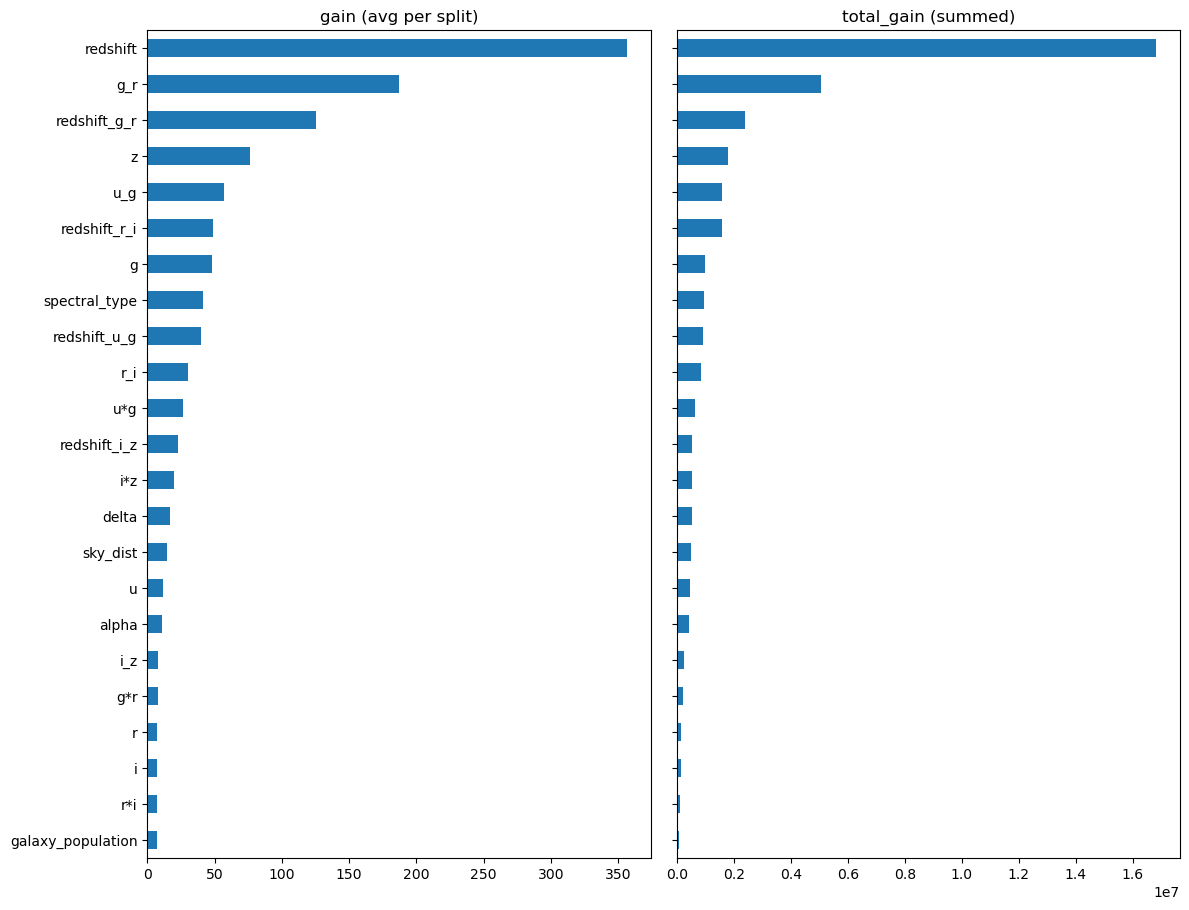

In [56]:
booster = model.get_booster()

imp = pd.DataFrame({
  'gain':       booster.get_score(importance_type='gain'),
  'total_gain': booster.get_score(importance_type='total_gain'),
}).reindex(features).fillna(0)
# reindex+fillna(0): features never used in a split are absent from get_score

fig, axes = plt.subplots(1, 2, figsize=(12, 0.4 * len(imp)), sharey=True)
imp.sort_values('gain')['gain'].plot.barh(ax=axes[0], title='gain (avg per split)')
imp.sort_values('total_gain')['total_gain'].plot.barh(ax=axes[1], title='total_gain (summed)')
plt.tight_layout()
plt.show()


In [57]:
imp.sort_values(ascending=False, by='total_gain')

,gain,total_gain
redshift,356.289673,1.680903e+07
g_r,125.168266,5.050540e+06
redshift_g_r,76.090630,2.396550e+06
z,57.306782,1.805794e+06
u_g,39.867630,1.588047e+06
redshift_r_i,49.081009,1.576776e+06
g,41.378040,1.003252e+06
spectral_type,186.792877,9.662796e+05
redshift_u_g,30.513029,9.386723e+05
r_i,19.473593,8.495744e+05


In [58]:
df = (test_df
          .pipe(copy_data)
          .pipe(clean_data)
          # .pipe(remove_outliers)
          .pipe(remove_duplicates)
          .pipe(make_new_features)
           )

In [59]:
df[categorical_features] = df[categorical_features].astype('category')

In [60]:
df

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,u_g,g_r,r_i,i_z,u*g,g*r,r*i,i*z,redshift_u_g,redshift_g_r,redshift_r_i,redshift_i_z,sky_dist
0,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence,1.716387,0.865497,0.906151,0.977908,519.553811,462.877133,425.519849,387.499489,0.736403,0.371335,0.388777,0.419564,123.067602
1,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence,2.564112,1.606658,0.871833,0.172640,556.302178,463.132096,411.747608,391.004034,2.223866,1.393463,0.756145,0.149731,223.430382
2,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud,0.952958,0.923319,0.980640,0.393909,358.917604,324.254080,290.837096,268.059890,0.213686,0.207040,0.219893,0.088328,173.577617
3,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence,1.594174,0.856696,0.252526,-0.281462,497.723032,444.963508,422.035709,422.626511,0.106024,0.056977,0.016795,-0.018719,184.909377
4,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence,2.450301,1.520808,1.683673,0.345342,568.234428,478.312718,410.623921,371.180896,2.394478,1.486161,1.645315,0.337474,223.018868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247430,248.013903,49.533434,21.563545,21.716868,21.670791,21.265478,21.558618,1.214520,A/F,Blue_Cloud,-0.153323,0.046076,0.405314,-0.293141,468.292644,470.621709,460.839728,458.454310,-0.186214,0.055961,0.492262,-0.356025,252.911955
247431,226.823885,52.635936,21.434441,21.075412,20.778300,20.962333,21.010822,1.004950,A/F,Blue_Cloud,0.359029,0.297112,-0.184034,-0.048489,451.739665,437.911217,435.561638,440.435857,0.360806,0.298583,-0.184945,-0.048729,232.851061
247432,232.879335,44.948125,23.294670,22.336583,20.121142,19.405430,18.744581,0.269394,M,Red_Sequence,0.958087,2.215441,0.715712,0.660849,520.323335,449.437547,390.459395,363.746638,0.258103,0.596826,0.192808,0.178029,237.177399
247433,351.396802,2.451824,20.882944,20.902010,20.222812,20.551737,20.278339,1.199392,G/K,Blue_Cloud,-0.019066,0.679198,-0.328925,0.273398,436.495495,422.697422,415.613910,416.755083,-0.022868,0.814625,-0.394510,0.327911,351.405355


In [61]:
preds = xgb_final_model.predict(df[features])

In [62]:
preds

array([0, 0, 0, ..., 0, 1, 0], shape=(247435,))

In [63]:
submission_df = pd.DataFrame(test_df['id'].copy())

In [64]:
submission_df['class'] = preds

In [65]:
submission_df

,id,class
0,577347,0
1,577348,0
2,577349,0
3,577350,2
4,577351,0
...,...,...
247430,824777,1
247431,824778,1
247432,824779,0
247433,824780,1


In [66]:
submission_df['class'] = submission_df['class'].map({0: 'GALAXY', 1: 'QSO', 2: 'STAR'})

In [67]:
submission_df['class'].value_counts()

class
GALAXY    157730
QSO        51316
STAR       38389
Name: count, dtype: int64

In [68]:
try:
    last_submission = pd.read_csv(find_last_submission_file())
except:
    last_submission = None

In [69]:
submission_df

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
...,...,...
247430,824777,QSO
247431,824778,QSO
247432,824779,GALAXY
247433,824780,QSO


In [70]:
if last_submission is None:
    submission_df.to_csv('./archive/submission_01.csv', index=False)
    print('saving file')
else:
    
    if all(last_submission['class'].value_counts() == submission_df['class'].value_counts()):
        # they are the same, don't same
        print('skipping save')
    else:
        submission_df.to_csv(find_next_submission_file(), index=False)
        print('saving file')

saving file
